In [1]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import math
import pandas as pd
import matplotlib as mpl
import os
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import gaussian_kde

In [2]:
# ----- SET GLOBAL MATPLOTLIB PARAMS -----

dpi = 300

mpl.rcParams['xtick.labelsize']=5
mpl.rcParams['ytick.labelsize']=5

mpl.rcParams['axes.titlesize']=7
mpl.rcParams['axes.labelsize']=6
mpl.rcParams["axes.titlepad"]=12
mpl.rcParams['axes.linewidth']=1
mpl.rcParams["axes.spines.right"]=False
mpl.rcParams["axes.spines.top"]=False

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

plt.rcParams['svg.fonttype'] = 'none'

plt.rcParams['savefig.dpi'] = dpi
plt.rcParams['figure.dpi']= dpi
plt.rcParams['figure.constrained_layout.use'] = True

plt.rcParams['savefig.transparent'] = True

# colors
acols = [[0.627451,   0.57254905, 0.37254903], # all colors
    [0.9607843,  0.7882353,  0.15294118],
    [0.34901962, 0.35686275, 0.49019608],
    [0.24705882, 0.30588236, 0.9607843 ]]

fcols = acols[0:2] # female colors, WT first
mcols = acols[2:] # male colors, WT first

# whisker dimensions
whiskspacer = 0.15
whiskpos = -whiskspacer

# plotting parameters
medlw = 1.5 # median linewidth
boxalpha = 0.5 # transparency for boxplot face color
caps = False # don't put caps on the error bars
bwidth = 0.9 # box width
ppad = 0.0085*2 # size of pvalue offset and height of bracket legs
plw = 0.8 # line thickness for pvalue bracket

# stats parameters
palpha = 0.05

# programatically set positions
dotdist = 0.15
errdist = 0.15
psdist = 1
gtdist = 1.5
start = 0

# set labels
lbls = ['WT','Scn2a$ \Delta $1a/+']
xlab = ''
ylab = 'fraction of assay'

# output directory for figure files
outdir = 'M:\\scn2a-paper-GWJSNH\\manuscript_v2\\figure_panels'

# save figures?
savefigs = False

# print stats?
printstats = True

In [3]:
# ----- DEFINE FUNCTIONS -----

def decide_pval_text(pval,palpha):

    if pval>palpha+0.015:
        ptxt = 'n.s.'
    elif palpha<pval<palpha+0.015:
        ptxt = f'p = {pval:.2f}'
    elif palpha/50<pval<palpha:
        ptxt='*'
    elif palpha/500<pval<palpha/50:
        ptxt ='**'
    elif palpha/5000<pval<palpha/500:
        ptxt = '***'
    else:
        ptxt = '****'

    return ptxt

def add_pair_to_plot_box(df,grp1,grp2,statkey,ax,col1,col2,startx,dotdist,errdist,psdist,whiskpos,ptxt):

    # -- GROUP 1 --
    tdf = df[df['GT']==grp1].copy().reset_index(drop=True)
    tcol=col1

    max1 = np.max(tdf[statkey])
    
    # plot group 1 dots
    ax.plot(np.zeros(tdf.shape[0])+startx+dotdist, tdf[statkey], 'o', markerfacecolor=tcol,markeredgecolor='k',zorder=4, ms=5, mew=1, alpha = 1)
    
    # plot group 1 boxplot
    boxprops = dict(linewidth=1, facecolor=tcol+[0.5],edgecolor=tcol)
    medianprops = dict(linewidth=medlw, color=tcol)
    whiskprops = dict(linewidth=0, color=tcol,alpha=boxalpha)

    bplot = ax.boxplot(tdf[statkey],positions=[startx],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False)
    
    whiskprops = dict(linewidth=1, color=tcol)
    medianprops = dict(linewidth=0, color=None)
    ax.boxplot(tdf[statkey],positions=[startx+whiskpos],showcaps=caps,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False,showbox=False,medianprops=medianprops)

    # -- GROUP 2 --    
    tdf = df[df['GT']==grp2].copy().reset_index(drop=True)
    tcol=col2

    max2 = np.max(tdf[statkey])
    
    # plot stranger dots
    ax.plot(np.zeros(tdf.shape[0])+startx+psdist-dotdist, tdf[statkey], 'o', markerfacecolor=tcol,markeredgecolor='k',zorder=4, ms=5, mew=1, alpha=1)

    # plot stranger boxplot
    boxprops = dict(linewidth=1, facecolor=tcol+[0.5],edgecolor=tcol)
    medianprops = dict(linewidth=medlw, color=tcol)
    whiskprops = dict(linewidth=0, color=tcol,alpha=boxalpha)
    bplot = ax.boxplot(tdf[statkey],positions=[startx+psdist],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False)
    
    whiskprops = dict(linewidth=1, color=tcol)
    medianprops = dict(linewidth=0, color=None)
    ax.boxplot(tdf[statkey],positions=[(startx+psdist-whiskpos)],showcaps=caps,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False,showbox=False,medianprops=medianprops)
    
    # # plot stats test result
    # bottom, top = plt.ylim()  # return the current ylim
    # ppad = np.max([max1,max2])/20
    # y, h = np.max([max1,max2]) + 12*ppad*np.max([max1,max2]), ppad
    # px1 = startx
    # px2 = startx+psdist
    # ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
    # plt.text((px1+px2)*.5, y+h+0.1*h, ptxt, ha='center', va='bottom', color='k',size=6)

    # axis parameters
    ax.spines['bottom'].set_visible(False)
    ax.set_xticks([start,start+psdist],labels=lbls,size=6)
    ax.tick_params(axis='x', which='both',length=0)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)

    return np.max([max1,max2])

In [4]:
# ----- LOAD AND FILTER DATA -----
assay = 'aggression'
assaydur = 1200
data = pd.read_csv(os.path.join('..','all_annotations.csv')).drop(labels=['Unnamed: 0','id'],axis=1)
data = data[data.assay==assay].copy().reset_index(drop=True)

boxDotPlot_aggression_Investigate_female.svg
MannwhitneyuResult(statistic=96.0, pvalue=0.16438404758801328)
0.07731583333333333
boxDotPlot_aggression_Investigate_male.svg
MannwhitneyuResult(statistic=52.0, pvalue=0.1051925051200414)
0.036554166666666665


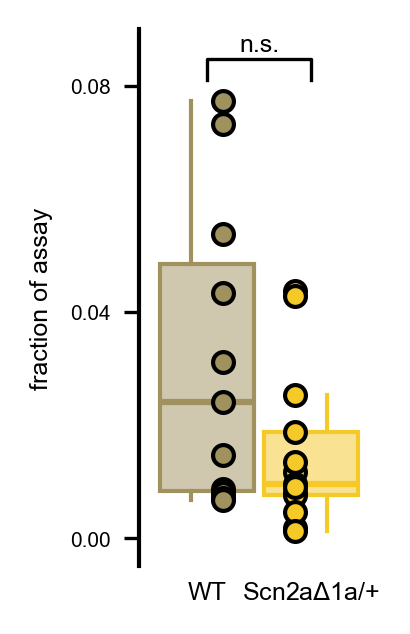

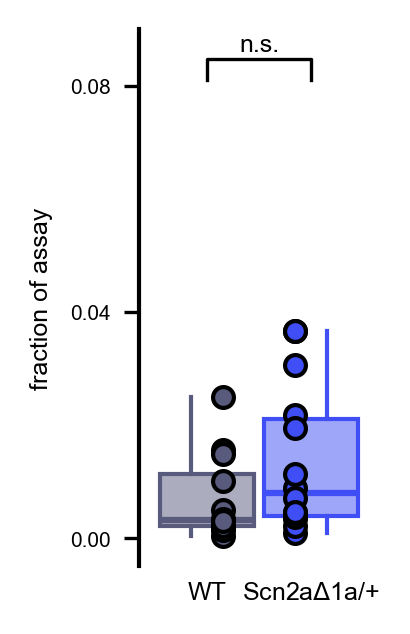

In [26]:
# ----- PLOT INDIVIDUAL BEHAVIORS -----
# behaviors: sniff, huddle, investigate

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']
i=0

# filter to relevant single behavior
blist = [behavs[i]]
fdat = data[data.behavior.isin(blist)].copy().reset_index(drop=True)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

# organize and sum total behavior time
sums = fdat.groupby(by=['pair_tag','GT','sex']).duration.sum().reset_index()
sums['fraction']=sums['duration']/assaydur

axes = []
maxes = []
ptxts = []

# plot
for sex in sexes:
    if sex=='male':
        sexlet = 'M'
        cols = mcols
    else:
        sexlet = 'F'
        cols = fcols

    fname = f'boxDotPlot_{assay}_{bstr}{sex}.svg'
    print(fname)

    fsums = sums[sums['sex']==sexlet].copy().reset_index(drop=True)

    # do stats etc
    ures = scipy.stats.mannwhitneyu(fsums[fsums['GT']=='WT']['duration'],fsums[fsums['GT']=='Het']['duration'])
    pval = ures.pvalue
    ptxt = decide_pval_text(pval,palpha)
    ptxts.append(ptxt)

    if printstats:
        print(ures)

    # make figure
    figsz = (1.25,2) # total size of figure
    fig, ax = plt.subplots(figsize=figsz)
    axes.append(ax)

    # make plot
    mx = add_pair_to_plot_box(fsums,'WT','Het','fraction',ax,cols[0],cols[1],start,dotdist,errdist,psdist,whiskpos,ptxt)
    print(mx)
    maxes.append(mx)

    # plot stats test result
    ppad = np.max(maxes)/20
    y, h = np.max(maxes) + 12*ppad*np.max(maxes), ppad
    px1 = start
    px2 = start+psdist

for ax,ptxt in zip(axes,ptxts):
    ax.set_ylim([-0.005,0.09])
    ax.set_yticks([0,0.04,0.08])
    ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
    ax.text((px1+px2)*.5, y+h+0.1*h, ptxt, ha='center', va='bottom', color='k',size=6)

    if savefigs:
        plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

boxDotPlot_aggression_Sniff_female.svg
MannwhitneyuResult(statistic=63.0, pvalue=0.643011484398551)
0.1248525
boxDotPlot_aggression_Sniff_male.svg
MannwhitneyuResult(statistic=57.0, pvalue=0.1728784373144301)
0.1514625


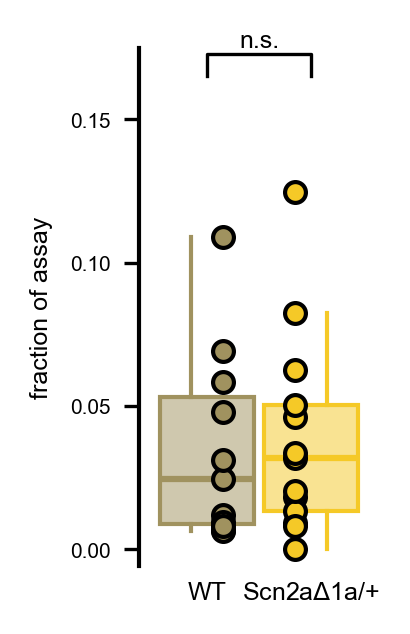

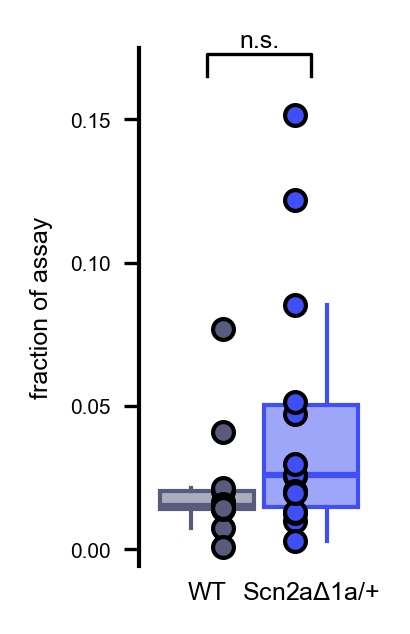

In [27]:
# ----- PLOT INDIVIDUAL BEHAVIORS -----
# behaviors: sniff, huddle, investigate

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']
i=1

# filter to relevant single behavior
blist = [behavs[i]]
fdat = data[data.behavior.isin(blist)].copy().reset_index(drop=True)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

# organize and sum total behavior time
sums = fdat.groupby(by=['pair_tag','GT','sex']).duration.sum().reset_index()
sums['fraction']=sums['duration']/assaydur

axes = []
maxes = []
ptxts = []

# plot
for sex in sexes:
    if sex=='male':
        sexlet = 'M'
        cols = mcols
    else:
        sexlet = 'F'
        cols = fcols

    fname = f'boxDotPlot_{assay}_{bstr}{sex}.svg'
    print(fname)

    fsums = sums[sums['sex']==sexlet].copy().reset_index(drop=True)

    # do stats etc
    ures = scipy.stats.mannwhitneyu(fsums[fsums['GT']=='WT']['duration'],fsums[fsums['GT']=='Het']['duration'])
    pval = ures.pvalue
    ptxt = decide_pval_text(pval,palpha)
    ptxts.append(ptxt)

    if printstats:
        print(ures)

    # make figure
    figsz = (1.25,2) # total size of figure
    fig, ax = plt.subplots(figsize=figsz)
    axes.append(ax)

    # make plot
    mx = add_pair_to_plot_box(fsums,'WT','Het','fraction',ax,cols[0],cols[1],start,dotdist,errdist,psdist,whiskpos,ptxt)
    print(mx)
    maxes.append(mx)

    # plot stats test result
    ppad = np.max(maxes)/20
    y, h = np.max(maxes) + 12*ppad*np.max(maxes), ppad
    px1 = start
    px2 = start+psdist

for ax,ptxt in zip(axes,ptxts):
    ax.set_ylim([-0.006,0.175])
    ax.set_yticks([0,0.05,0.1,0.15])
    ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
    ax.text((px1+px2)*.5, y+h+0.1*h, ptxt, ha='center', va='bottom', color='k',size=6)

    if savefigs:
        plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

boxDotPlot_aggression_Huddle_female.svg
Ttest_indResult(statistic=-0.7673289152876208, pvalue=0.452588387605264)
MannwhitneyuResult(statistic=63.0, pvalue=0.8777166830732149)
0.07249916666666666
boxDotPlot_aggression_Huddle_male.svg
Ttest_indResult(statistic=-2.423138134885594, pvalue=0.02453486253434926)
MannwhitneyuResult(statistic=35.0, pvalue=0.0604981907185908)
0.21892083333333331


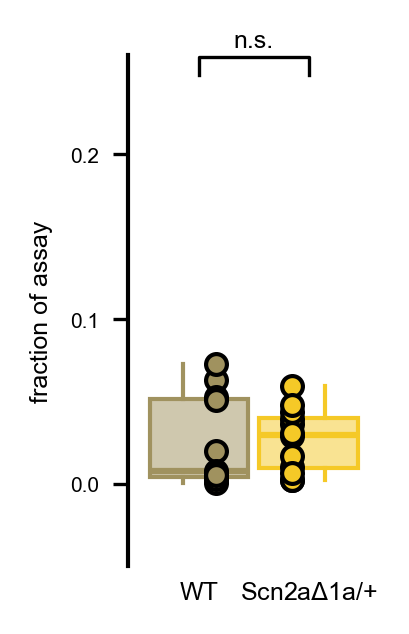

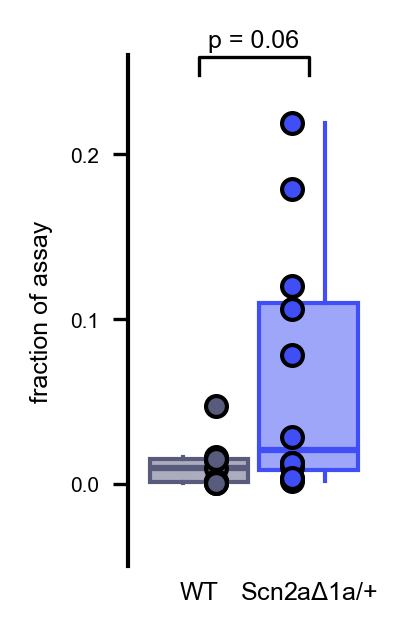

In [39]:
# ----- PLOT INDIVIDUAL BEHAVIORS -----
# behaviors: sniff, huddle, investigate

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']
i=2

# filter to relevant single behavior
blist = [behavs[i]]
fdat = data[data.behavior.isin(blist)].copy().reset_index(drop=True)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

# organize and sum total behavior time
sums = fdat.groupby(by=['pair_tag','GT','sex']).duration.sum().reset_index()
sums['fraction']=sums['duration']/assaydur

axes = []
maxes = []
ptxts = []

# plot
for sex in sexes:
    if sex=='male':
        sexlet = 'M'
        cols = mcols
    else:
        sexlet = 'F'
        cols = fcols

    fname = f'boxDotPlot_{assay}_{bstr}{sex}.svg'
    print(fname)

    fsums = sums[sums['sex']==sexlet].copy().reset_index(drop=True)

    # do stats etc
    ures = scipy.stats.mannwhitneyu(fsums[fsums['GT']=='WT']['duration'],fsums[fsums['GT']=='Het']['duration'])
    pval = ures.pvalue
    ptxt = decide_pval_text(pval,palpha)
    ptxts.append(ptxt)

    tres = scipy.stats.ttest_ind(np.log(fsums[fsums['GT']=='WT']['duration']),np.log(fsums[fsums['GT']=='Het']['duration']),equal_var=False)
    print(tres)

    if printstats:
        print(ures)

    # make figure
    figsz = (1.25,2) # total size of figure
    fig, ax = plt.subplots(figsize=figsz)
    axes.append(ax)

    # make plot
    mx = add_pair_to_plot_box(fsums,'WT','Het','fraction',ax,cols[0],cols[1],start,dotdist,errdist,psdist,whiskpos,ptxt)
    print(mx)
    maxes.append(mx)

    # plot stats test result
    ppad = np.max(maxes)/20
    y, h = np.max(maxes) + 12*ppad*np.max(maxes), ppad
    px1 = start
    px2 = start+psdist

for ax,ptxt in zip(axes,ptxts):
    ax.set_ylim([-0.05,0.26])
    ax.set_yticks([0,0.1,0.2])
    ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
    ax.text((px1+px2)*.5, y+h+0.3*h, ptxt, ha='center', va='bottom', color='k',size=6)

    if savefigs:
        plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

boxDotPlot_aggression_Investigate_Sniff_female.svg
MannwhitneyuResult(statistic=82.0, pvalue=0.562342605179145)
0.18220083333333334
boxDotPlot_aggression_Investigate_Sniff_male.svg
MannwhitneyuResult(statistic=54.0, pvalue=0.12918685117545492)
0.18801666666666667


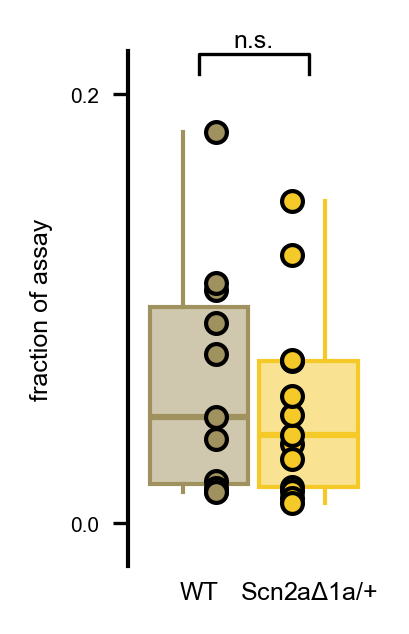

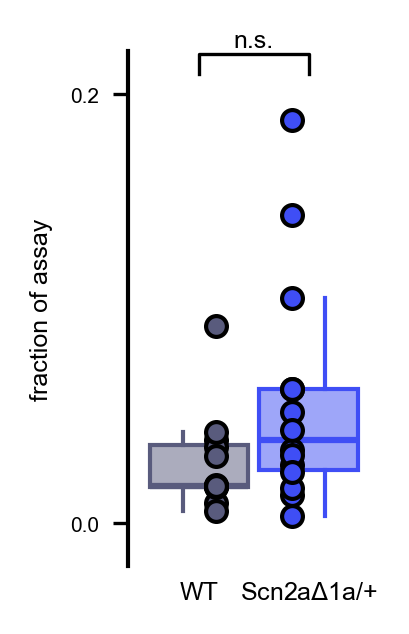

In [23]:
# ----- PLOT GROUPS OF BEHAVIORS -----
# behaviors: sniff, huddle, investigate

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']

# filter to relevant single behavior
blist = [behavs[0],behavs[1]]
fdat = data[data.behavior.isin(blist)].copy().reset_index(drop=True)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

# organize and sum total behavior time
sums = fdat.groupby(by=['pair_tag','GT','sex']).duration.sum().reset_index()
sums['fraction']=sums['duration']/assaydur

axes = []
maxes = []
ptxts = []

# plot
for sex in sexes:
    if sex=='male':
        sexlet = 'M'
        cols = mcols
    else:
        sexlet = 'F'
        cols = fcols

    fname = f'boxDotPlot_{assay}_{bstr}{sex}.svg'
    print(fname)

    fsums = sums[sums['sex']==sexlet].copy().reset_index(drop=True)

    # do stats etc
    ures = scipy.stats.mannwhitneyu(fsums[fsums['GT']=='WT']['duration'],fsums[fsums['GT']=='Het']['duration'])
    pval = ures.pvalue
    ptxt = decide_pval_text(pval,palpha)
    ptxts.append(ptxt)

    if printstats:
        print(ures)

    # make figure
    figsz = (1.25,2) # total size of figure
    fig, ax = plt.subplots(figsize=figsz)
    axes.append(ax)

    # make plot
    mx = add_pair_to_plot_box(fsums,'WT','Het','fraction',ax,cols[0],cols[1],start,dotdist,errdist,psdist,whiskpos,ptxt)
    print(mx)
    maxes.append(mx)

    # plot stats test result
    ppad = np.max(maxes)/20
    y, h = np.max(maxes) + 12*ppad*np.max(maxes), ppad
    px1 = start
    px2 = start+psdist

for ax,ptxt in zip(axes,ptxts):
    ax.set_ylim([-0.02,0.22])
    ax.set_yticks([0,0.2])
    ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
    ax.text((px1+px2)*.5, y+h+0.1*h, ptxt, ha='center', va='bottom', color='k',size=6)

    if savefigs:
        plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

boxDotPlot_aggression_Investigate_Sniff_Huddle_female.svg
Ttest_indResult(statistic=-0.04249816101434799, pvalue=0.9664849340223858)
MannwhitneyuResult(statistic=72.0, pvalue=1.0)
0.23295833333333335
boxDotPlot_aggression_Investigate_Sniff_Huddle_male.svg
Ttest_indResult(statistic=-1.8693469764920283, pvalue=0.07382488503677817)
MannwhitneyuResult(statistic=46.0, pvalue=0.053756704975859326)
0.3237083333333333


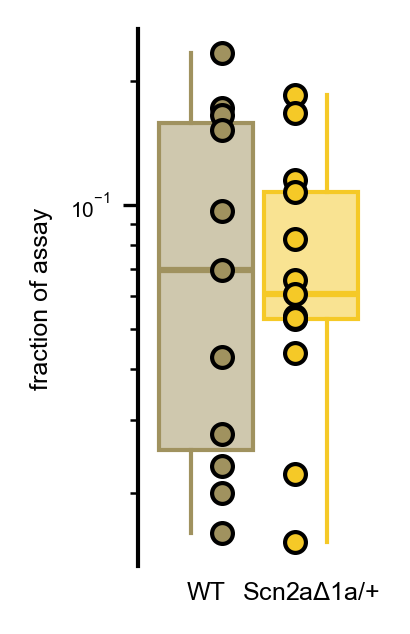

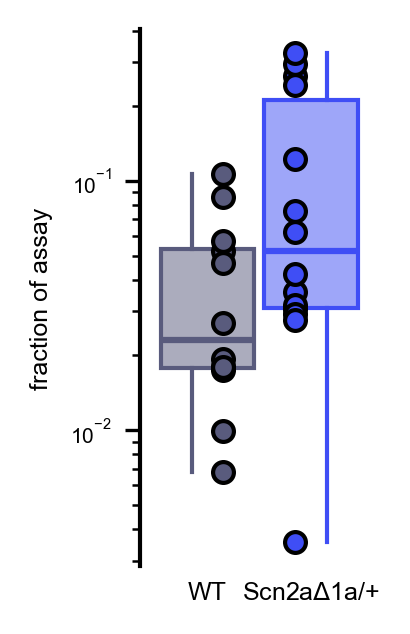

In [43]:
# ----- PLOT GROUPS OF BEHAVIORS -----
# behaviors: sniff, huddle, investigate

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']

# filter to relevant single behavior
blist = behavs
fdat = data[data.behavior.isin(blist)].copy().reset_index(drop=True)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

# organize and sum total behavior time
sums = fdat.groupby(by=['pair_tag','GT','sex']).duration.sum().reset_index()
sums['fraction']=sums['duration']/assaydur

axes = []
maxes = []
ptxts = []

# plot
for sex in sexes:
    if sex=='male':
        sexlet = 'M'
        cols = mcols
    else:
        sexlet = 'F'
        cols = fcols

    fname = f'boxDotPlot_{assay}_{bstr}{sex}.svg'
    print(fname)

    fsums = sums[sums['sex']==sexlet].copy().reset_index(drop=True)

    # do stats etc
    ures = scipy.stats.mannwhitneyu(fsums[fsums['GT']=='WT']['duration'],fsums[fsums['GT']=='Het']['duration'])
    pval = ures.pvalue
    ptxt = decide_pval_text(pval,palpha)
    pxts.append(ptxt)

    # log transform and ttest
    # variance test
    bartres = scipy.stats.bartlett(np.log(fsums[fsums['GT']=='WT']['duration']),np.log(fsums[fsums['GT']=='Het']['duration']))
    eqvar = bartres.pvalue>0.05
    tres = scipy.stats.ttest_ind(np.log(fsums[fsums['GT']=='WT']['duration']),np.log(fsums[fsums['GT']=='Het']['duration']),equal_var=eqvar)
    print(tres)

    if printstats:
        print(ures)

    # make figure
    figsz = (1.25,2) # total size of figure
    fig, ax = plt.subplots(figsize=figsz)
    axes.append(ax)

    # make plot
    mx = add_pair_to_plot_box(fsums,'WT','Het','fraction',ax,cols[0],cols[1],start,dotdist,errdist,psdist,whiskpos,ptxt)
    print(mx)
    maxes.append(mx)

    # plot stats test result
    ppad = np.max(maxes)/20
    y, h = np.max(maxes) + 5*ppad*np.max(maxes), ppad
    px1 = start
    px2 = start+psdist

for ax,ptxt in zip(axes,ptxts):

    ax.set_yscale('log')
    
    # ax.set_ylim([-0.02,0.38])
    # ax.set_yticks([0,0.05,0.1,0.15,0.2,0.25,0.3,0.35])
    # ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
    # ax.text((px1+px2)*.5, y+h+0.3*h, ptxt, ha='center', va='bottom', color='k',size=6)

    if savefigs:
        plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

boxDotPlot_aggression_Investigate_Sniff_Huddle_female.svg
TtestResult(statistic=np.float64(-0.04249816101434799), pvalue=np.float64(0.9664849340223858), df=np.float64(22.0))
MannwhitneyuResult(statistic=np.float64(72.0), pvalue=np.float64(1.0))
5.633181167472654
boxDotPlot_aggression_Investigate_Sniff_Huddle_male.svg
TtestResult(statistic=np.float64(-1.8693469764920283), pvalue=np.float64(0.07382488503677817), df=np.float64(24.0))
MannwhitneyuResult(statistic=np.float64(46.0), pvalue=np.float64(0.053756704975859326))
5.96216446139643


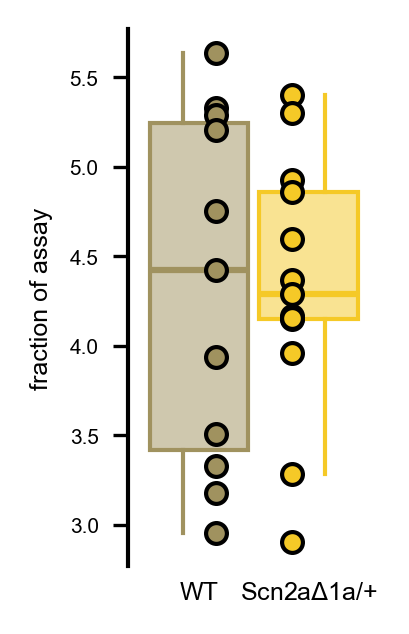

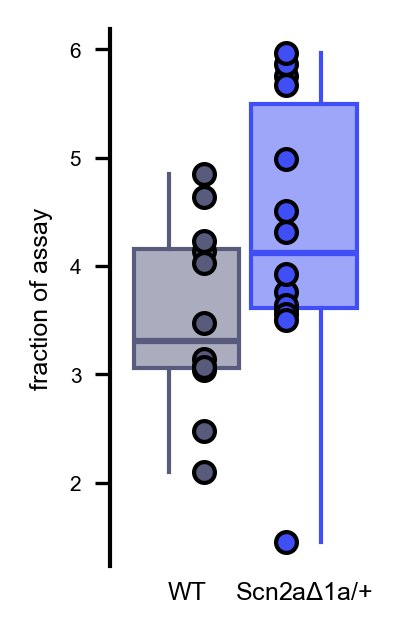

In [15]:
# ----- PLOT GROUPS OF BEHAVIORS -----
# behaviors: sniff, huddle, investigate

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']

# filter to relevant single behavior
blist = behavs
fdat = data[data.behavior.isin(blist)].copy().reset_index(drop=True)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

# organize and sum total behavior time
sums = fdat.groupby(by=['pair_tag','GT','sex']).duration.sum().reset_index()
sums['fraction']=sums['duration']/assaydur

axes = []
maxes = []
ptxts = []

# plot
for sex in sexes:
    if sex=='male':
        sexlet = 'M'
        cols = mcols
    else:
        sexlet = 'F'
        cols = fcols

    fname = f'boxDotPlot_{assay}_{bstr}{sex}.svg'
    print(fname)

    fsums = sums[sums['sex']==sexlet].copy().reset_index(drop=True)

    # do stats etc
    ures = scipy.stats.mannwhitneyu(fsums[fsums['GT']=='WT']['duration'],fsums[fsums['GT']=='Het']['duration'])
    pval = ures.pvalue
    ptxt = decide_pval_text(pval,palpha)
    pxts.append(ptxt)

    # log transform and ttest
    # variance test
    bartres = scipy.stats.bartlett(np.log(fsums[fsums['GT']=='WT']['duration']),np.log(fsums[fsums['GT']=='Het']['duration']))
    eqvar = bartres.pvalue>0.05
    tres = scipy.stats.ttest_ind(np.log(fsums[fsums['GT']=='WT']['duration']),np.log(fsums[fsums['GT']=='Het']['duration']),equal_var=eqvar)
    print(tres)

    if printstats:
        print(ures)

    # make figure
    figsz = (1.25,2) # total size of figure
    fig, ax = plt.subplots(figsize=figsz)
    axes.append(ax)

    # make plot
    logtrans = fsums.copy()
    logtrans['duration'] = np.log(fsums.duration)
    mx = add_pair_to_plot_box(logtrans,'WT','Het','duration',ax,cols[0],cols[1],start,dotdist,errdist,psdist,whiskpos,ptxt)
    print(mx)
    maxes.append(mx)

    # plot stats test result
    ppad = np.max(maxes)/20
    y, h = np.max(maxes) + 5*ppad*np.max(maxes), ppad
    px1 = start
    px2 = start+psdist

for ax,ptxt in zip(axes,ptxts):

    ax.set_yscale('log')
    
    # ax.set_ylim([-0.02,0.38])
    # ax.set_yticks([0,0.05,0.1,0.15,0.2,0.25,0.3,0.35])
    # ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
    # ax.text((px1+px2)*.5, y+h+0.3*h, ptxt, ha='center', va='bottom', color='k',size=6)

    if savefigs:
        plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

In [10]:
axes

[<Axes: ylabel='fraction of assay'>, <Axes: ylabel='fraction of assay'>]